### Cell 1: Import Libraries and Load Data

This cell imports the necessary libraries for data manipulation, model building, and evaluation. It then loads the data from the '/content/sample_data/data.csv' file into a pandas DataFrame and displays the first few rows to inspect the data.

In [ ]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from copy import deepcopy


from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('/content/sample_data/data.csv')
df.head()

,Date,Open,High,Low,Close
0,2000-01-03,1482.15,1592.90,1482.15,1592.2
1,2000-01-04,1594.40,1641.95,1594.40,1638.7
2,2000-01-05,1634.55,1635.50,1555.05,1595.8
3,2000-01-06,1595.80,1639.00,1595.80,1617.6
4,2000-01-07,1616.60,1628.25,1597.20,1613.3


### Cell 2: Prepare Data for Time Series Forecasting

This cell defines a function `return_pairs` to create input-output pairs for time series forecasting. It takes a column (time series data) and the number of past days to consider (`days`) and returns two NumPy arrays: `X` (input sequences) and `y` (target values). The code then applies this function to the 'High' column of the DataFrame for different `day_chunks` (30, 60, and 90 days) and stores the resulting input-output pairs in the `chunked_data` dictionary. Finally, it creates a list `chunk_pairs` to easily iterate through the generated data chunks.

In [ ]:
def return_pairs(column, days):
    pricess = list(column)
    X = []
    y = []
    for i in range(len(pricess) - days):
        X.append(pricess[i:i+days])
        y.append(pricess[i+days])
    return np.array(X), np.array(y)

target_columns =  ['High']
day_chunks =  [30, 60, 90]

chunked_data = {}

for col in target_columns:
    for days in day_chunks:
        key_X = f"X_{col}_{days}"
        key_y = f"y_{col}_{days}"
        X, y = return_pairs(df[col], days)
        chunked_data[key_X] = X
        chunked_data[key_y] = y


chunk_pairs = []

for key in chunked_data.keys():
    if key.startswith("X_"):
        y_key = key.replace("X_", "y_")
        if y_key in chunked_data:
            chunk_pairs.append([key, y_key])

### Cell 3: Define Deep Learning Model Architectures

This cell defines functions to build different types of recurrent neural network (RNN) models using TensorFlow/Keras. It includes functions for building a simple RNN, LSTM, GRU, and Bidirectional LSTM model. Each function takes the input shape as an argument and returns a compiled Keras Sequential model with a Dense layer for regression output.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Bidirectional


def build_rnn(input_shape):
    model = Sequential([
        SimpleRNN(50, activation='tanh', input_shape=input_shape),
        Dense(1)   # regression output
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm(input_shape):
    model = Sequential([
        LSTM(50, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru(input_shape):
    model = Sequential([
        GRU(50, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_bilstm(input_shape):
    model = Sequential([
        Bidirectional(LSTM(50, activation='tanh'), input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

### Cell 4: Define Machine Learning and Deep Learning Models

This cell initializes lists and dictionaries to store the machine learning and deep learning models to be trained. `ml_models` contains a list of tuples, each with the model name and the model object (currently only KNeighborsRegressor). `dl_models` is a dictionary where keys are the model names (RNN, LSTM, GRU, Bidirectional_LSTM) and values are the functions defined in the previous cell to build these models.

In [ ]:
ml_models = [("KNN", KNeighborsRegressor())]

dl_models = {
    "RNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "Bidirectional_LSTM": build_bilstm
}

### Cell 5: Train Models

This cell trains both the machine learning and deep learning models on the prepared data chunks. It iterates through the `chunk_pairs`, splits the data into training and testing sets, and then trains each model. For ML models, it uses `model.fit()`. For DL models, it reshapes the input data for the RNN layers and uses `model_dl.fit()` with a specified number of epochs and batch size. After training, it calculates the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) for both training and testing sets and stores these metrics in the `trained_models` dictionary.

In [ ]:
trained_models = {}

for X, y in tqdm(chunk_pairs):
    X_data = chunked_data[X]
    y_data = chunked_data[y]

    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.1, random_state=42
    )

    # ML models
    for model_name, model in tqdm(ml_models):
        key = model_name + '_' + X[2:]
        model_copy = deepcopy(model)
        model_copy.fit(X_train, y_train)

        y_train_pred = model_copy.predict(X_train)
        y_test_pred = model_copy.predict(X_test)

        trained_models[key] = {
            'train_mae': mean_absolute_error(y_train, y_train_pred),
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'test_mae': mean_absolute_error(y_test, y_test_pred),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred))
        }

    # DL models
    X_train_rnn = np.expand_dims(X_train, -1)
    X_test_rnn = np.expand_dims(X_test, -1)

    for model_name, builder in tqdm(dl_models.items()):
        key = model_name + '_' + X[2:]
        model_dl = builder((X_train.shape[1], 1))

        model_dl.fit(X_train_rnn, y_train, epochs=50, batch_size=8, verbose=0)

        y_train_pred = model_dl.predict(X_train_rnn).flatten()
        y_test_pred = model_dl.predict(X_test_rnn).flatten()

        trained_models[key] = {
            'train_mae': mean_absolute_error(y_train, y_train_pred),
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'test_mae': mean_absolute_error(y_test, y_test_pred),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred))
        }


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


### Cell 6: Create Results DataFrame

This cell creates a pandas DataFrame `results_df` from the `trained_models` dictionary. It structures the data to have columns for 'Model', 'train_mae', 'train_rmse', 'test_mae', and 'test_rmse'. It then sorts the DataFrame by 'test_mae' in ascending order and displays the top 50 rows, allowing for easy comparison of model performance based on test MAE.

In [ ]:
results_df = pd.DataFrame([
    {"Model": name, **metrics}
    for name, metrics in trained_models.items()])

results_df.sort_values(by = 'test_mae', ascending = True).head(50)

,Model,train_mae,train_rmse,test_mae,test_rmse
10,KNN_High_90,36.929140,58.769966,48.790144,74.204848
5,KNN_High_60,36.850899,58.333589,52.819089,82.674612
0,KNN_High_30,42.646429,68.669169,56.933037,89.679421
1,RNN_High_30,6390.416364,8844.447442,5893.124902,8447.896768
6,RNN_High_60,6417.844146,8876.775724,5962.535530,8379.379577
11,RNN_High_90,6435.838043,8883.826689,6158.251094,8600.822935
3,GRU_High_30,6993.687418,9394.910293,6474.625857,8978.803830
4,Bidirectional_LSTM_High_30,7118.304750,9488.204965,6599.119569,9069.232797
13,GRU_High_90,6944.681479,9359.761635,6645.763197,9069.861576
8,GRU_High_60,7157.272719,9529.041447,6675.762906,9019.865207


### Cell 7: Visualize Model Performance

This cell generates bar plots to visualize the performance of the trained models based on 'test_mae' and 'test_rmse'. It iterates through the specified metrics, creates a bar plot for each, sets the labels and title, rotates the x-axis labels for readability, and displays the plot. This provides a clear visual comparison of how different models performed on the test data.

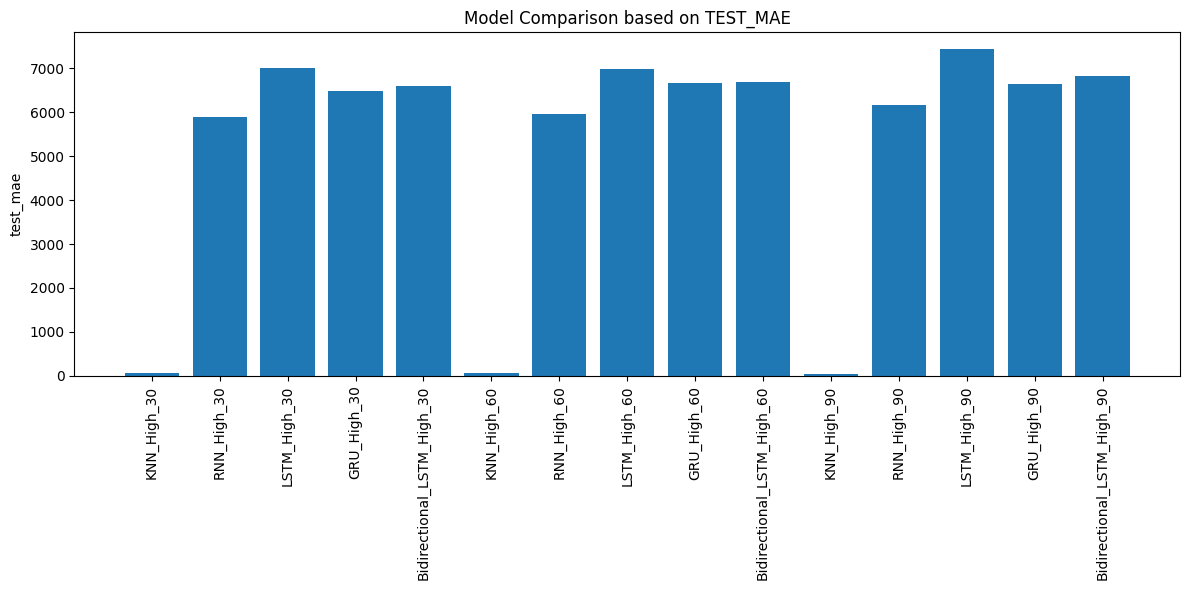

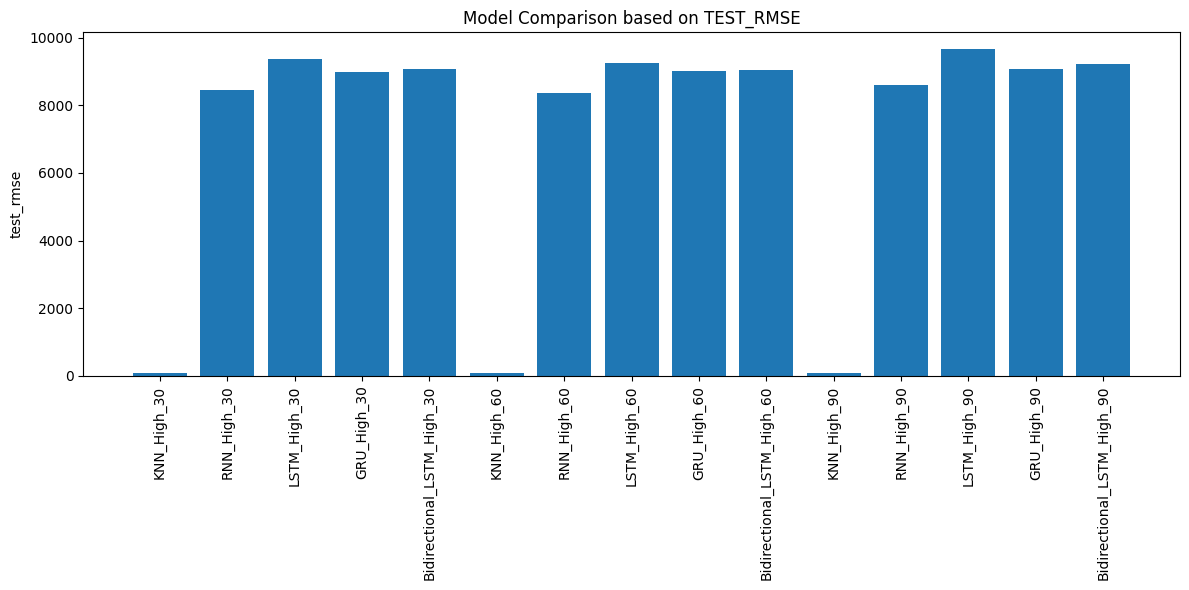

In [ ]:
import matplotlib.pyplot as plt

metrics = ['test_mae', 'test_rmse']
for metric in metrics:
    plt.figure(figsize=(12, 6))
    plt.bar(results_df['Model'], results_df[metric])
    plt.ylabel(metric)
    plt.title(f'Model Comparison based on {metric.upper()}')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

### Cell 8: Save and Load Trained Models and Results

This cell saves the `results_df` DataFrame to a CSV file named 'models.csv' and the `trained_models` dictionary (containing the trained model objects and/or metrics) to a joblib file named 'trained_models.joblib'. It then loads the saved joblib file back into the `loaded_models` variable. This allows for persistence of the training results and trained models for future use without retraining.

In [ ]:
import joblib

results_df.to_csv('models.csv')
joblib.dump(trained_models, 'trained_models.joblib')

loaded_models = joblib.load('trained_models.joblib')

In [ ]:
loaded_models['KNN_High_90']
model = loaded_models['KNN_High_90']

In [ ]:
print(type(loaded_models['KNN_High_90']))
print(loaded_models['KNN_High_90'])


<class 'dict'>
{'train_mae': 36.929139593002496, 'train_rmse': np.float64(58.769966157340505), 'test_mae': 48.79014446227931, 'test_rmse': np.float64(74.20484820380837)}


### Conclusion

This notebook demonstrates a process for time series forecasting using both traditional machine learning (KNN) and deep learning (RNN, LSTM, GRU, Bidirectional LSTM) models. The data is prepared by creating input-output sequences based on different historical time windows (30, 60, and 90 days). Multiple models are trained and evaluated based on Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) on a test set. The results are summarized in a DataFrame and visualized to compare the performance of different models and time windows. The trained models and the performance results are saved for future use.

Based on the results:

*   The KNN models generally performed significantly better than the tested deep learning models for this specific dataset and forecasting task, achieving much lower MAE and RMSE values.
*   Among the KNN models, the one trained with a 90-day lookback window ('KNN_High_90') showed the best performance on the test set.
*   The deep learning models, while powerful for sequence data, may require further tuning of hyperparameters, architecture, or more extensive data for better performance on this particular problem compared to the simple KNN approach.